<a href="https://colab.research.google.com/github/d4nd14z/DataAnalytics/blob/main/ITTF_TableTennis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **ITTF - International Table Tennis Federation**<br/>@author: Daniel M. Díaz<br/>@since: March 31, 2026

### **1. Importación de librerias y unión de los tres datasets**

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', None)  # Mostrar todas las columnas
pd.set_option('display.max_rows', None)     # Mostrar todas las filas


In [ ]:
try:
  path1 = '/content/drive/MyDrive/Mi Portafolio/ITTF - International Table Tennis Federation/data/ittf_player_info.csv'
  path2 = '/content/drive/MyDrive/Mi Portafolio/ITTF - International Table Tennis Federation/data/ittf_rankings.csv'
  path3 = '/content/drive/MyDrive/Mi Portafolio/ITTF - International Table Tennis Federation/data/ittf_rankings_women.csv'
  if not os.path.exists(path1) or not os.path.exists(path2) or not os.path.exists(path3):
    raise FileNotFoundError(f"(ERROR): No se han encontrado los archivos del conjunto de datos.")
  df1 = pd.read_csv(path1, sep=";")
  df2 = pd.read_csv(path2, sep=";")
  df3 = pd.read_csv(path3, sep=";")
except Exception as ex:
  print(f"(ERROR): NO se han podido leer los archivos del conjunto de datos.")



In [ ]:
# Renombrar las columnas en los archivos df2 y df3 para que coincidan con el nombre de la columna de df1.
df2 = df2.rename(columns={'ID': 'Player ID'})
df3 = df3.rename(columns={'ID': 'Player ID'})

In [ ]:

# df1.info()
# df2.info()
# df3.info()
# Apilar los tres DataFrames uno debajo del otro
df_final = pd.concat([df1, df2, df3], ignore_index=True)

#Exportar el resultado final de los tres DATASETS
df_final.to_csv('/content/drive/MyDrive/Mi Portafolio/ITTF - International Table Tennis Federation/data/full_data.csv', index=False)

### **2. Lectura del dataset completo de datos**

In [ ]:
path = '/content/drive/MyDrive/Mi Portafolio/ITTF - International Table Tennis Federation/data/full_data.csv'
try:
  if not os.path.exists(path):
    raise FileNotFoundError(f"(ERROR) No se ha encontrado el dataset completo de datos")
  df = pd.read_csv(path, low_memory=False)
except Exception as ex:
  print(f"(ERROR) No se ha podido leer el archivos del conjunto completo de datos")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 511202 entries, 0 to 511201
Data columns (total 16 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Player ID        511202 non-null  int64  
 1   Name             511187 non-null  object 
 2   Assoc            511078 non-null  object 
 3   Gender           511187 non-null  object 
 4   Birth year       28184 non-null   float64
 5   Activity         37496 non-null   object 
 6   Playing hand     9507 non-null    object 
 7   Playing style    9507 non-null    object 
 8   Grip             9507 non-null    object 
 9   Rank             473582 non-null  float64
 10  Previous         473001 non-null  float64
 11  Points           473582 non-null  float64
 12  Previous Points  473001 non-null  float64
 13  WeekNum          473582 non-null  float64
 14  MonthNum         473582 non-null  float64
 15  YearNum          473582 non-null  float64
dtypes: float64(8), int64(1), object(7)
mem

### Eliminar todos los jugadores que estén inactivos y eliminar los jugadores de los que se desconoce su actividad.

In [ ]:
df.drop(df[df['Activity'] == 'Inactive'].index, inplace=True)
df.dropna(subset=['Activity'], inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 27661 entries, 0 to 37619
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Player ID        27661 non-null  int64  
 1   Name             27661 non-null  object 
 2   Assoc            27658 non-null  object 
 3   Gender           27661 non-null  object 
 4   Birth year       25703 non-null  float64
 5   Activity         27661 non-null  object 
 6   Playing hand     8989 non-null   object 
 7   Playing style    8989 non-null   object 
 8   Grip             8989 non-null   object 
 9   Rank             0 non-null      float64
 10  Previous         0 non-null      float64
 11  Points           0 non-null      float64
 12  Previous Points  0 non-null      float64
 13  WeekNum          0 non-null      float64
 14  MonthNum         0 non-null      float64
 15  YearNum          0 non-null      float64
dtypes: float64(8), int64(1), object(7)
memory usage: 3.6+ MB


In [ ]:
# Hay 27661 Jugadores "Activos"
# df["Assoc"].unique()
# df["Gender"].unique()

# Reemplazar los valores NaN de la columna "Birth Year" por ceros.
df['Birth year'] = df['Birth year'].fillna(0)
df['Birth year'] = df['Birth year'].astype(int)

df["Activity"].unique()

df["Playing hand"].unique()
df['Playing hand'] = df['Playing hand'].replace('-', np.nan)

df['Playing style'].unique()
df['Playing style'] = df['Playing style'].replace('-', np.nan)

df['Grip'].unique()
df['Grip'] = df['Grip'].replace('-', np.nan)

df['Rank'].unique() #Todos los valores son nulos !!!  jajajajaja

df["Previous"].unique()  #Todos los valores son nulos !!!  jajajajaja

df["Points"].unique() #Todos los valores son nulos !!!  jajajajaja

df["Previous Points"].unique() #Todos los valores son nulos !!!  jajajajaja

df["WeekNum"].unique() #Todos los valores son nulos !!!  jajajajaja

df["MonthNum"].unique() #Todos los valores son nulos !!!  jajajajaja

df["YearNum"].unique() #Todos los valores son nulos !!!  jajajajaja


df.head(10)

,Player ID,Name,Assoc,Gender,Birth year,Activity,Playing hand,Playing style,Grip,Rank,Previous,Points,Previous Points,WeekNum,MonthNum,YearNum
0,113207,A'ASA Junella,ASA,Female,1976,Active,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,113276,A. QADER Bakhtiyar,IRQ,Male,0,Active,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,100002,AAA Shirchin,MGL,Male,0,Active,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,112267,AAL ALI Faisal,UAE,Male,1991,Active,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,145778,AALTONEN Gabriela,SWE,Female,2009,Active,Right-handed,Attacker,Shakehand,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,100003,AALTONEN Joni,FIN,Male,1976,Active,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,100185,AAMAN Erik,SWE,Male,1985,Active,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12,145022,AARRAD Wahiba,MAR,Female,2003,Active,Right-handed,Attacker,Shakehand,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13,100006,AAS Merje,EST,Female,1976,Active,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15,116168,AASEBO Anna,NOR,Female,1995,Active,Right-handed,Attacker,Shakehand,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Tablas comparativas.

tabla = pd.crosstab(df['Playing style'], df['Playing hand'], normalize='index') * 100

tabla

# Estadísticas
# El 13.1 % de los jugadores de estilo de Ataque son "Zurdos"
# El 2.91 % de los jugadores de estilo de Defensa son "Zurdos"
# El 86.89 % de los jugadores de estilo de Ataque son "Derechos"
# El 97.08 % de los jugadores de estilo de Defensa son "Derechos"

Playing hand,Left-handed,Right-handed
Playing style,,
Attacker,13.109410,86.890590
Defender,2.919708,97.080292


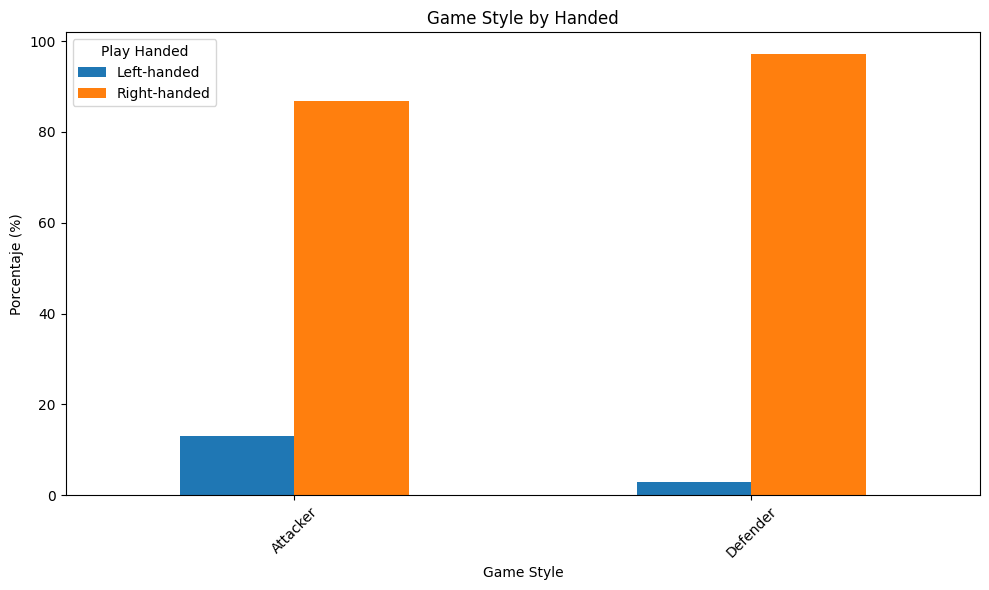

In [ ]:
# Barras agrupadas
tabla.plot(kind='bar', figsize=(10, 6))
plt.title('Game Style by Handed')
plt.xlabel('Game Style')
plt.ylabel('Porcentaje (%)')
plt.xticks(rotation=45)
plt.legend(title='Play Handed')
plt.tight_layout()
plt.show()